In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import numpy as np
from sklearnex import patch_sklearn
patch_sklearn()
from sklearn.decomposition import PCA
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, recall_score, roc_auc_score, confusion_matrix
from reader import prepare_qsm_dataset
from util import seed_everything, mask_crop as mask_crop_fn
from train import calibrate_balanced

# --- CONFIG ---
device = torch.device("cuda:6" if torch.cuda.is_available() else "cpu")
N_PCA_COMPONENTS = 16 
N_FOLDS = 5 
NEG_WEIGHT = 12.0  
GAMMA = 12.0
JITTER_STD = 0.1 
TARGET_DIM = 128
IMG_AUG_STD = 0.05
PSEUDO_THRESHOLD = 0.0  # Use all unlabeled data
seed_everything(0)

# --- STANDALONE METRICS HELPER ---
def get_m(y_true, y_pred, y_prob):
    acc = accuracy_score(y_true, y_pred)
    sens = recall_score(y_true, y_pred)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0
    auc = roc_auc_score(y_true, y_prob)
    return [acc, sens, spec, auc]

class PassThrough(nn.Module):
    def forward(self, x, **kwargs): return x

# ============================================================
# MODELS
# ============================================================
class FocalLoss(nn.Module):
    def __init__(self, alpha=1, gamma=2):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, inputs, targets, weight=None):
        bce_loss = F.binary_cross_entropy(inputs, targets, weight=weight, reduction='none')
        pt = torch.exp(-bce_loss)
        focal_loss = self.alpha * (1 - pt)**self.gamma * bce_loss
        return focal_loss.mean()

# class ClinicalTransformer(nn.Module):
#     def __init__(self, n_inputs, embed_dim=32, n_heads=4, n_layers=2):
#         super().__init__()
#         self.embedding = nn.Linear(1, embed_dim)
#         encoder_layer = nn.TransformerEncoderLayer(d_model=embed_dim, nhead=n_heads, dim_feedforward=embed_dim*2)
#         self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)
#         self.fc = nn.Linear(embed_dim * n_inputs, 1)

#     def forward(self, x, return_logit=False, **kwargs):
#         if x.ndim == 1: x = x.unsqueeze(0)
#         x = x.unsqueeze(-1)
#         x = self.embedding(x)
#         x = x.permute(1, 0, 2)
#         x = self.transformer(x)
#         x = x.permute(1, 0, 2).flatten(1)
#         logit = self.fc(x).squeeze()
#         if logit.ndim == 0: logit = logit.unsqueeze(0) # handle single-sample batch
#         return logit if return_logit else torch.sigmoid(logit)

class ClinicalTransformer(nn.Module):
    def __init__(self, n_inputs, embed_dim=32, n_heads=4, n_layers=2):
        super().__init__()
        self.tau = nn.Parameter(torch.tensor(1024.0)) 
        self.n_inputs = n_inputs
        self.embedding = nn.Linear(1, embed_dim)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim, 
            nhead=n_heads, 
            dim_feedforward=embed_dim*2,
            dropout=0.1
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)
        self.fc = nn.Linear(embed_dim * n_inputs, 1)
    def forward(self, x, return_logit=False, **kwargs):
        if x.ndim == 1: 
            x = x.unsqueeze(0)
        # Spectral Variance Hierarchy Weighting
        if x.shape[1] == self.n_inputs:
            indices = torch.arange(self.n_inputs).to(x.device).float()
            omega = torch.exp(-indices / self.tau)
            x = x*omega
        x = x.unsqueeze(-1)          
        x = self.embedding(x)        
        # Permute to [Seq, Batch, Embed]
        x = x.permute(1, 0, 2)       
        x = self.transformer(x)      
        # Permute back to [Batch, Seq, Embed] before flattening
        x = x.permute(1, 0, 2).flatten(1)
        logit = self.fc(x).squeeze()
        if logit.ndim == 0: 
            logit = logit.unsqueeze(0) 
        return logit if return_logit else torch.sigmoid(logit)

class ResidualWrapper(nn.Module):
    def __init__(self, m_ct, m_res):
        super().__init__()
        self.m_ct = m_ct
        self.m_res = m_res
    def forward(self, x_joint, **kwargs):
        x_pca = x_joint[:, :N_PCA_COMPONENTS]
        x_clin = x_joint[:, N_PCA_COMPONENTS:]
        l_clin = self.m_ct(x_clin, return_logit=True)
        l_res = self.m_res(x_pca, return_logit=True)
        return torch.sigmoid(l_clin + l_res)

def robust_flatten(img_np, target_dim=TARGET_DIM):
    t = torch.from_numpy(img_np).float().unsqueeze(0).unsqueeze(0)
    resized = F.interpolate(t, size=(target_dim, target_dim), mode='bilinear', align_corners=False)
    return resized.numpy().flatten()

# ============================================================
# DATA PREPARATION (Including Unlabeled)
# ============================================================
dataset_msw = prepare_qsm_dataset('MSW', '/media/mts_dbs/dbs/all/nii/qsm_115/im', '/media/mts_dbs/dbs/all/nii/seg_ps/', '/data/Ali/RadDBS-QSM/data/docs/dbs_03292024.csv', 'msw_cache_6d_cv.pt', load_cache=True, mask_crop_fn=mask_crop_fn, cv_pad=False)
dataset_chh = prepare_qsm_dataset('CHH', '/media/mts_dbs/chh/nii/qsm/', '/media/mts_dbs/chh/roi/', '/media/mts_dbs/chh/xlsx/chh_subjects_table1_20240729.csv', 'chh_cache_6d_cv.pt', load_cache=True, mask_crop_fn=mask_crop_fn, cv_pad=False)

def get_slice_level_data(dataset, include_unlabeled=False):
    all_imgs, all_clins, all_lbls, subj_map = [], [], [], []
    for i in range(len(dataset)):
        img, clin, lbl, _ = dataset[i]
        # Keep labeled data or, if requested, keep unlabeled data (lbl == -1)
        if (lbl != -1) or (include_unlabeled and lbl == -1):
            img_np = img.numpy().squeeze()
            if img_np.ndim == 3:
                for s in range(img_np.shape[2]):
                    all_imgs.append(robust_flatten(img_np[:, :, s]))
                    all_clins.append(clin.numpy()); all_lbls.append(lbl); subj_map.append(i)
            else:
                all_imgs.append(robust_flatten(img_np))
                all_clins.append(clin.numpy()); all_lbls.append(lbl); subj_map.append(i)
    return np.array(all_imgs), np.array(all_clins), np.array(all_lbls), np.array(subj_map)

# Split Training data into Labeled and Unlabeled sets
X_full_slices, X_full_clin, y_full_slices, full_subj_map = get_slice_level_data(dataset_msw, include_unlabeled=True)
labeled_mask = (y_full_slices != -1)

X_tr_slices, X_tr_clin, y_tr_slices, tr_subj_map = X_full_slices[labeled_mask], X_full_clin[labeled_mask], y_full_slices[labeled_mask], full_subj_map[labeled_mask]
X_un_slices, X_un_clin, y_un_slices, un_subj_map = X_full_slices[~labeled_mask], X_full_clin[~labeled_mask], y_full_slices[~labeled_mask], full_subj_map[~labeled_mask]

# Test set (always labeled)
X_te_slices, X_te_clin, y_te_slices, te_subj_map = get_slice_level_data(dataset_chh)

# PCA / Scaling fitted on MSW Labeled slices
img_scaler = StandardScaler().fit(X_tr_slices)
pca = PCA(n_components=N_PCA_COMPONENTS, random_state=0, whiten=True).fit(img_scaler.transform(X_tr_slices))

X_tr_pca = pca.transform(img_scaler.transform(X_tr_slices))
X_te_pca = pca.transform(img_scaler.transform(X_te_slices))
X_un_pca = pca.transform(img_scaler.transform(X_un_slices)) if len(X_un_slices) > 0 else []

# ============================================================
# TWO-STAGE TRAINING LOOP
# ============================================================
unique_subjs = np.unique(tr_subj_map)
y_unique = np.array([y_tr_slices[tr_subj_map == s][0] for s in unique_subjs])
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=0)

fold_preds_ct, fold_preds_sp = [], []
fold_ths_ct, fold_ths_sp = [], []
criterion = FocalLoss(gamma=GAMMA)

for fold, (t_subj_idx, v_subj_idx) in enumerate(skf.split(unique_subjs, y_unique)):
    t_idx_slices = np.isin(tr_subj_map, unique_subjs[t_subj_idx])
    v_idx_slices = np.isin(tr_subj_map, unique_subjs[v_subj_idx])
    
    X_tr_clin_subjs = np.array([X_tr_clin[tr_subj_map == s][0] for s in unique_subjs[t_subj_idx]])
    y_tr_subjs = y_unique[t_subj_idx]
    
    scaler_c = StandardScaler().fit(X_tr_clin_subjs)
    xt_clin_subjs = torch.tensor(scaler_c.transform(X_tr_clin_subjs), dtype=torch.float32).to(device)
    yt_subjs = torch.tensor(y_tr_subjs, dtype=torch.float32).to(device)

    # --- STAGE 1: Subject-Level Training (Clinical Only) ---
    m_ct = ClinicalTransformer(n_inputs=X_tr_clin.shape[1]).to(device)
    opt_ct = optim.Adam(m_ct.parameters(), lr=1e-4, betas=(0.9,0.999))
    
    for epoch in range(100):
        m_ct.train(); opt_ct.zero_grad()
        c_jitter = torch.randn_like(xt_clin_subjs) * JITTER_STD
        weights = torch.where(yt_subjs == 0, torch.tensor(NEG_WEIGHT).to(device), torch.tensor(1.0).to(device))
        probs = m_ct(xt_clin_subjs + c_jitter)
        loss = criterion(probs, yt_subjs, weight=weights)
        loss.backward(); opt_ct.step()

    # --- STAGE 2: Slice-Level Training (Residual Imaging + Pseudo-labeling) ---
    for param in m_ct.parameters(): param.requires_grad = False
    m_ct.eval()
    
    m_res = ClinicalTransformer(n_inputs=N_PCA_COMPONENTS).to(device)
    opt_res = optim.Adam(m_res.parameters(), lr=1e-4, betas=(0.9,0.999))

    # Prepare Labeled data
    xt_pca_slices = torch.tensor(X_tr_pca[t_idx_slices], dtype=torch.float32).to(device)
    xt_clin_slices = torch.tensor(scaler_c.transform(X_tr_clin[t_idx_slices]), dtype=torch.float32).to(device)
    yt_slices = torch.tensor(y_tr_slices[t_idx_slices], dtype=torch.float32).to(device)

    # Prepare Pseudo-labeled data (silver labels from teacher m_ct)
    xt_pca_pseudo, xt_clin_pseudo, yt_pseudo = None, None, None
    if len(X_un_pca) > 0:
        with torch.no_grad():
            un_c = torch.tensor(scaler_c.transform(X_un_clin), dtype=torch.float32).to(device)
            un_p = torch.tensor(X_un_pca, dtype=torch.float32).to(device)
            un_probs = m_ct(un_c)
            
            # Confidence Mask
            mask = (un_probs > PSEUDO_THRESHOLD) | (un_probs < (1 - PSEUDO_THRESHOLD))
            if mask.any():
                xt_pca_pseudo = un_p[mask]
                xt_clin_pseudo = un_c[mask]
                yt_pseudo = (un_probs[mask] > 0.5).float()

    for epoch in range(150):
        m_res.train(); opt_res.zero_grad()
        
        # 1. Labeled Loss
        i_aug = torch.randn_like(xt_pca_slices) * IMG_AUG_STD
        w_l = torch.where(yt_slices == 0, torch.tensor(NEG_WEIGHT).to(device), torch.tensor(1.0).to(device))
        l_probs = torch.sigmoid(m_ct(xt_clin_slices, True) + m_res(xt_pca_slices + i_aug, True))
        loss_main = criterion(l_probs, yt_slices, weight=w_l)
        
        # 2. Pseudo-labeled Loss
        loss_pseudo = 0
        if yt_pseudo is not None:
            p_probs = torch.sigmoid(m_ct(xt_clin_pseudo, True) + m_res(xt_pca_pseudo, True))
            loss_pseudo = criterion(p_probs, yt_pseudo)
            
        (loss_main).backward(); opt_res.step() #+ 0.0 * loss_pseudo).backward(); opt_res.step()

    # --- CALIBRATION & TEST ---
    m_sp_wrap = ResidualWrapper(m_ct, m_res)
    with torch.no_grad():
        v_subj_ids = unique_subjs[v_subj_idx]
        v_probs_ct, v_probs_sp, v_labels = [], [], []
        for s_id in v_subj_ids:
            s_mask = (tr_subj_map == s_id)
            v_c = torch.tensor(scaler_c.transform(X_tr_clin[s_mask]), dtype=torch.float32).to(device)
            v_p = torch.tensor(X_tr_pca[s_mask], dtype=torch.float32).to(device)
            v_probs_ct.append(m_ct(v_c).mean().cpu().item())
            v_probs_sp.append(m_sp_wrap(torch.cat([v_p, v_c], dim=1)).mean().cpu().item())
            v_labels.append(y_tr_slices[s_mask][0])

    f_th_ct = calibrate_balanced(PassThrough(), None, np.array(v_probs_ct), np.array(v_labels), 'cpu')
    f_th_sp = calibrate_balanced(PassThrough(), None, np.array(v_probs_sp), np.array(v_labels), 'cpu')
    fold_ths_ct.append(f_th_ct); fold_ths_sp.append(f_th_sp)

    with torch.no_grad():
        te_subj_ids = np.unique(te_subj_map)
        te_p_ct, te_p_sp = [], []
        for s_id in te_subj_ids:
            s_mask = (te_subj_map == s_id)
            t_c = torch.tensor(scaler_c.transform(X_te_clin[s_mask]), dtype=torch.float32).to(device)
            t_p = torch.tensor(X_te_pca[s_mask], dtype=torch.float32).to(device)
            te_p_ct.append(m_ct(t_c).mean().cpu().item())
            te_p_sp.append(torch.sigmoid(m_ct(t_c, True) + m_res(t_p, True)).mean().cpu().item())
        fold_preds_ct.append(te_p_ct); fold_preds_sp.append(te_p_sp)

# ============================================================
# FINAL RESULTS & SIGNIFICANCE
# ============================================================
pct, psp = np.median(fold_preds_ct, axis=0), np.mean(fold_preds_sp, axis=0)
th_ct, th_sp = np.mean(fold_ths_ct), np.mean(fold_ths_sp)
y_te_unique = np.array([y_te_slices[te_subj_map == s][0] for s in np.unique(te_subj_map)])

res_ct = get_m(y_te_unique, (pct >= th_ct), pct)
res_sp = get_m(y_te_unique, (psp >= th_sp), psp)

#print(f"\n{'Metric':<15} | {'Clinical Only':<15} | {'Joint + Pseudo':<15}")
print(f"\n{'Metric':<15} | {'Joint':<15}")
print("-" * 55)
for i, name in enumerate(['Acc', 'Sens', 'Spec', 'AUC']):
    #print(f"{name:<15} | {res_ct[i]:<15.2f} | {res_sp[i]:<15.2f}")
    print(f"{name:<15} | {res_sp[i]:<15.4f}")
from scipy.stats import wilcoxon
err_clinical = np.abs(y_te_unique - pct)
err_joint = np.abs(y_te_unique - psp)
stat, p_val = wilcoxon(err_clinical, err_joint, alternative='greater')

print(f"\nWilcoxon p-value: {p_val:.4f}")

Intel(R) Extension for Scikit-learn* enabled (https://github.com/intel/scikit-learn-intelex)



Preparing MSW dataset (Forced 6-dim alignment) 
Pre-flight check: Validating MSW CSV mapping...
--- MSW CSV RAW MEANS ---
  > Age     : 62.13
  > Sex     : 0.26
  > Dur     : 8.47
  > LEDD    : 989.80
  > Off-Pre : 45.91
  > On-Pre  : 19.60

Final MSW Breakdown:
 - Unique Subjects on Disk: 111
 - Labeled Responders (1): 61
 - Labeled Non-Responders (0): 5
 - Unlabeled subjects (-1): 45
 - Verified Realized Means (Matched Data Only):
    > Age     : 63.08
    > Sex     : 0.26
    > Dur     : 8.44
    > LEDD    : 1003.95
    > Off-Pre : 45.62
    > On-Pre  : 19.55

❌ FULL MISSING LIST (45 subjects):
  [3, 4, 5, 8, 12, 13, 14, 17, 18, 21, 22, 24, 25, 27, 28, 31, 32, 34, 35, 37, 39, 40, 41, 42, 49, 50, 52, 54, 57, 61, 65, 67, 74, 76, 81, 82, 84, 88, 89, 94, 99, 101, 104, 105, 116]
Loaded cache with 7790 slices.

Preparing CHH dataset (Forced 6-dim alignment) 
Pre-flight check: Validating CHH CSV mapping...
--- CHH CSV RAW MEANS ---
  > Age     : 63.13
  > Sex     : 0.46
  > Dur     : 8.54

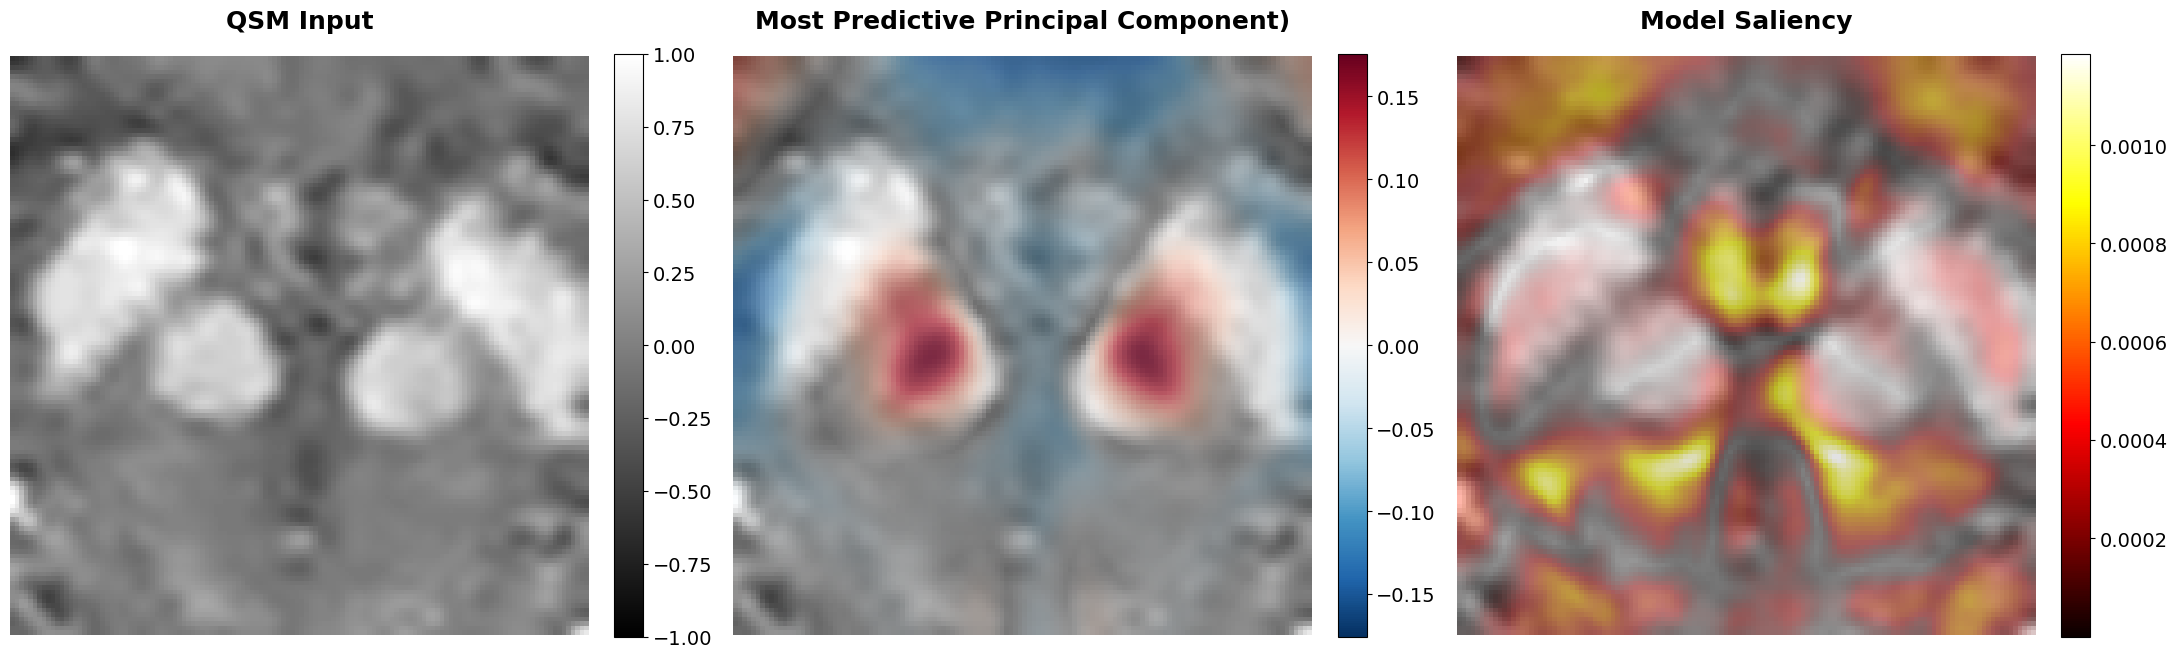

In [2]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.cm import ScalarMappable
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.cm import ScalarMappable
import numpy as np
import torch

def visualize_alpha_with_bigger_text(pca_model, image_scaler, joint_model, X_te_raw, sample_idx=0):
    joint_model.eval()
    
    # --- TEXT SIZE SETTINGS ---
    TITLE_SIZE = 18
    LABEL_SIZE = 14
    plt.rcParams.update({'font.size': LABEL_SIZE}) # Global tick size update
    
    # 1. Base Layer (Slice 40)
    slice_40_ref = X_te_raw[40].reshape(TARGET_DIM, TARGET_DIM)
    slice_40_rot = np.rot90(slice_40_ref, k=1)
    QSM_VMIN, QSM_VMAX = -1, 1
    
    # 2. Gradient Calculation (Moving this up to find the "Most Predictive" PC)
    s_mask = (te_subj_map == np.unique(te_subj_map)[sample_idx])
    sample_pca = torch.tensor(X_te_pca[s_mask], dtype=torch.float32).to(device)
    sample_pca.requires_grad_(True)
    sample_pca.retain_grad()
    
    sample_clin = torch.tensor(scaler_c.transform(X_te_clin[s_mask]), dtype=torch.float32).to(device)
    output = joint_model(torch.cat([sample_pca, sample_clin], dim=1))
    output.mean().backward()
    
    # Get gradients and find the index of the most predictive component
    grads = sample_pca.grad.mean(dim=0).cpu().numpy()
    most_predictive_idx = np.argmax(np.abs(grads))
    
    # 3. PCA Component (Now using the most predictive index)
    comp_pred = pca_model.components_[most_predictive_idx]
    feat_map = image_scaler.inverse_transform(comp_pred.reshape(1, -1)).reshape(TARGET_DIM, TARGET_DIM)
    feat_rot = np.rot90(feat_map, k=1)
    
    # 4. Saliency Map
    saliency_map = np.abs(np.dot(grads, pca_model.components_).reshape(TARGET_DIM, TARGET_DIM))
    saliency_rot = np.rot90(saliency_map, k=1)

    # Alpha logic (Unchanged)
    def get_rgba_overlay(data, cmap_name, max_alpha=0.8, center_zero=False):
        if center_zero:
            vabs = max(abs(data.min()), abs(data.max()))
            norm = mcolors.Normalize(vmin=-vabs, vmax=vabs)
        else:
            norm = mcolors.Normalize(vmin=data.min(), vmax=data.max())
        cmap = plt.get_cmap(cmap_name)
        rgba = cmap(norm(data))
        if center_zero:
            alpha_map = np.abs(norm(data) - 0.5) * 2
        else:
            alpha_map = (data - data.min()) / (data.max() - data.min() + 1e-8)
        rgba[..., 3] = alpha_map * max_alpha
        return rgba, norm

    pca_rgba, pca_norm = get_rgba_overlay(feat_rot, 'RdBu_r', center_zero=True)
    sali_rgba, sali_norm = get_rgba_overlay(saliency_rot, 'hot')

    # --- Plotting ---
    fig, axes = plt.subplots(1, 3, figsize=(22, 8))
    
    # Plot 1: QSM Input
    im1 = axes[0].imshow(slice_40_rot, cmap='gray', vmin=QSM_VMIN, vmax=QSM_VMAX)
    axes[0].set_title("QSM Input", fontsize=TITLE_SIZE, fontweight='bold', pad=20)
    cbar1 = fig.colorbar(im1, ax=axes[0], fraction=0.046, pad=0.04)
    cbar1.ax.tick_params(labelsize=LABEL_SIZE)
    
    # Plot 2: PCA Overlay
    axes[1].imshow(slice_40_rot, cmap='gray', vmin=QSM_VMIN, vmax=QSM_VMAX)
    axes[1].imshow(pca_rgba)
    axes[1].set_title(f"Most Predictive Principal Component)", fontsize=TITLE_SIZE, fontweight='bold', pad=20)
    sm2 = ScalarMappable(norm=pca_norm, cmap='RdBu_r')
    cbar2 = fig.colorbar(sm2, ax=axes[1], fraction=0.046, pad=0.04)
    cbar2.ax.tick_params(labelsize=LABEL_SIZE)
    
    # Plot 3: Saliency Overlay
    axes[2].imshow(slice_40_rot, cmap='gray', vmin=QSM_VMIN, vmax=QSM_VMAX)
    axes[2].imshow(sali_rgba)
    axes[2].set_title("Model Saliency", fontsize=TITLE_SIZE, fontweight='bold', pad=20)
    sm3 = ScalarMappable(norm=sali_norm, cmap='hot')
    cbar3 = fig.colorbar(sm3, ax=axes[2], fraction=0.046, pad=0.04)
    cbar3.ax.tick_params(labelsize=LABEL_SIZE)
    
    for ax in axes:
        ax.axis('off')
        
    plt.tight_layout()
    plt.show()

visualize_alpha_with_bigger_text(pca, img_scaler, m_sp_wrap, X_te_slices)

Total QSM Importance: 0.51%
Total Clinical Importance in Joint Model: 0.49%


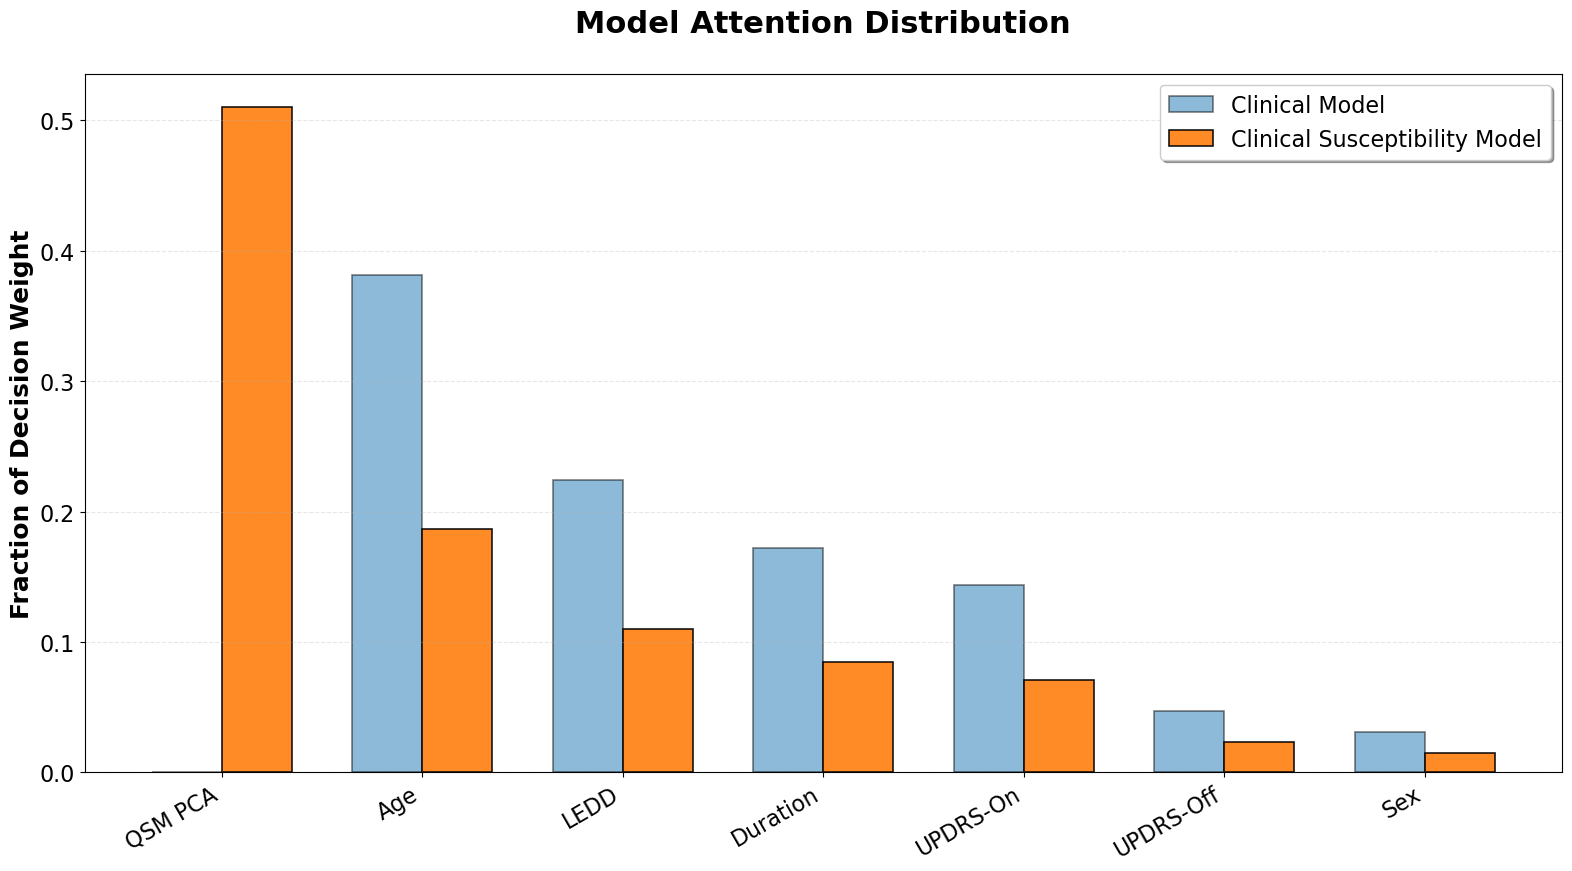

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import torch

def plot_total_imaging_contribution(clinical_model, joint_model, x_clin_raw, x_pca, scaler):
    clinical_model.eval()
    joint_model.eval()
    
    # --- 1. SET HIGH-VISIBILITY TEXT ---
    TITLE_SIZE, LABEL_SIZE, TICK_SIZE = 22, 18, 16
    plt.rcParams.update({'font.size': TICK_SIZE})
    
    x_clin_scaled = scaler.transform(x_clin_raw)
    
    def get_raw_importance(model, xc, xp=None, is_joint=False):
        xc_t = torch.tensor(xc, dtype=torch.float32).to(device)
        xc_t.requires_grad_(True)
        xc_t.retain_grad()
        
        if is_joint:
            xp_t = torch.tensor(xp, dtype=torch.float32).to(device)
            xp_t.requires_grad_(True)
            xp_t.retain_grad()
            out = model(torch.cat([xp_t, xc_t], dim=1))
        else:
            out = model(xc_t)
        
        model.zero_grad()
        out.mean().backward()
        
        # Mean Absolute Gradient for clinical features
        clin_imp = xc_t.grad.abs().mean(dim=0).cpu().numpy()
        
        if is_joint:
            # SUM of all PCA component gradients = Total Imaging Weight
            pca_imps = xp_t.grad.abs().mean(dim=0).cpu().numpy()
            total_pca_imp = np.sum(pca_imps)
            return clin_imp, total_pca_imp
        return clin_imp, 0.0

    # --- 2. COMPUTE & NORMALIZE (SUM TO 100%) ---
    # Clinical Model Baseline
    raw_clin_only, _ = get_raw_importance(clinical_model, x_clin_scaled, is_joint=False)
    pct_clin_only = (raw_clin_only / np.sum(raw_clin_only))
    
    # Joint Model: (Clin + TOTAL PCA) sums to 100%
    raw_joint_clin, raw_total_pca = get_raw_importance(joint_model, x_clin_scaled, xp=x_pca, is_joint=True)
    total_joint_mass = np.sum(raw_joint_clin) + raw_total_pca
    
    pct_joint_clin = (raw_joint_clin / total_joint_mass)
    pct_total_pca = (raw_total_pca / total_joint_mass)

    # --- 3. MAP NAMES & ALIGN DATA ---
    feature_names = ['Age', 'Sex', 'Duration', 'LEDD', 'UPDRS-Off', 'UPDRS-On']
    plot_names = feature_names + ['QSM PCA']
    
    plot_data_clin = np.append(pct_clin_only, 0.0)
    plot_data_joint = np.append(pct_joint_clin, pct_total_pca)

    # Sort based on Joint Model's total allocation
    sort_idx = np.argsort(plot_data_joint)[::-1]
    sorted_names = [plot_names[i] for i in sort_idx]
    sorted_clin = plot_data_clin[sort_idx]
    sorted_joint = plot_data_joint[sort_idx]

    # --- 4. PLOTTING ---
    indices = np.arange(len(plot_names))
    width = 0.35
    plt.figure(figsize=(16, 9))
    
    plt.bar(indices - width/2, sorted_clin, width, label='Clinical Model', 
            color='tab:blue', alpha=0.5, edgecolor='black', linewidth=1.2)
    
    plt.bar(indices + width/2, sorted_joint, width, label='Clinical Susceptibility Model', 
            color='tab:orange', alpha=0.9, edgecolor='black', linewidth=1.2)
    
    plt.ylabel('Fraction of Decision Weight', fontweight='bold', fontsize=LABEL_SIZE)
    plt.title('Model Attention Distribution', pad=30, fontweight='bold', fontsize=TITLE_SIZE)
    plt.xticks(indices, sorted_names, rotation=30, ha='right')
    
    # Display the final percentage for the paper
    print(f"Total QSM Importance: {pct_total_pca:.2f}%")
    print(f"Total Clinical Importance in Joint Model: {np.sum(pct_joint_clin):.2f}%")
    
    plt.legend(frameon=True, shadow=True)
    plt.grid(axis='y', linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.show()

# Run the total contribution plot
plot_total_imaging_contribution(m_ct, m_sp_wrap, X_te_clin, X_te_pca, scaler_c)

In [ ]:
from sklearn.metrics import balanced_accuracy_score

# ============================================================
# PERFORMANCE TABLE WITH BALANCED ACCURACY (IN-MEMORY)
# ============================================================

# 1. Prepare in-memory data from the last fold
v_y = np.array(v_labels)
v_p_ct = np.array(v_probs_ct)
v_p_sp = np.array(v_probs_sp)

# 2. Define a quick helper to include Balanced Acc
def get_extended_m(y_true, y_prob, threshold):
    y_pred = (y_prob >= threshold)
    acc = accuracy_score(y_true, y_pred)
    b_acc = balanced_accuracy_score(y_true, y_pred)
    sens = recall_score(y_true, y_pred)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0
    auc = roc_auc_score(y_true, y_prob)
    return [acc, b_acc, sens, spec, auc]

# 3. Calculate metrics
# Using the specific fold thresholds (f_th) and global test results (res_sp)
v_metrics_ct = get_extended_m(v_y, v_p_ct, f_th_ct)
v_metrics_sp = get_extended_m(v_y, v_p_sp, f_th_sp)

# For the Test set, we use the global mean threshold (th_sp) 
# and the previously calculated probabilities (psp)
te_metrics_sp = get_extended_m(y_te_unique, psp, th_sp)

# 4. Print Table
print(f"{'Extended Model Performance':^75}")
print("=" * 75)
print(f"{'Metric':<15} | {'Val (Clinical)':<15} | {'Val (Joint)':<15} || {'Test (Joint)':<15}")
print("-" * 75)

metrics_list = ['Acc', 'Bal-Acc', 'Sens (Rec)', 'Spec', 'AUC']
for i, name in enumerate(metrics_list):
    print(f"{name:<15} | {v_metrics_ct[i]:<15.4f} | {v_metrics_sp[i]:<15.4f} || {te_metrics_sp[i]:<15.4f}")

print("-" * 75)
print(f"Val Class Balance: {sum(v_y == 0)} Non-Resp / {sum(v_y == 1)} Resp")
print(f"Test Class Balance: {sum(y_te_unique == 0)} Non-Resp / {sum(y_te_unique == 1)} Resp")
print("=" * 75)